In [7]:
# Task 1

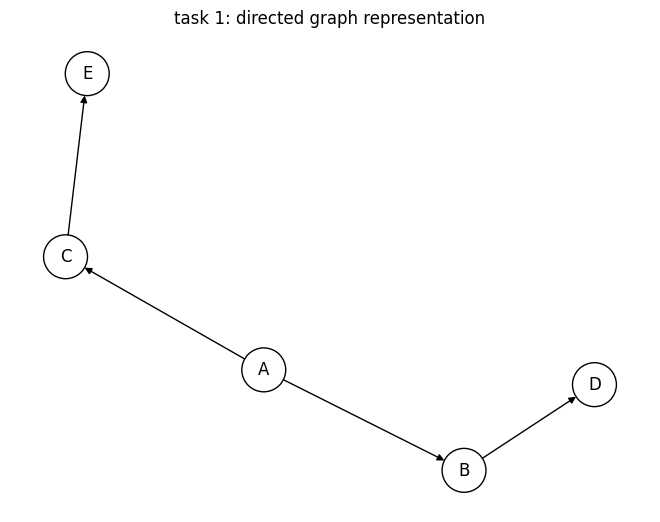

In [30]:
import networkx as nx
import matplotlib.pyplot as plt


graph = {
    'A': [('B',1),('C',1)],
    'B': [('D',1)],
    'C': [('E',1)],
    'D': [],
    'E': []
}
initial_state = 'A'
goal_state = 'E'

def get_successors(state):
    return graph.get(state, [])

def is_goal(state):
    return state == goal_state

def step_cost(current, neighbor):
    for n, cost in graph.get(current, []):
        if n == neighbor:
            return cost
    return None


def visualize_graph():
    G = nx.DiGraph()

    for node, neighbors in graph.items():
        for neighbor, cost in neighbors:
            G.add_edge(node, neighbor, weight=cost)

    nx.draw(G, with_labels=True, node_color='none',
            edgecolors='black',node_size=1000)

    plt.title("task 1: directed graph representation")
    plt.show()



if __name__ == "__main__":
    visualize_graph()


In [37]:
# Task 2

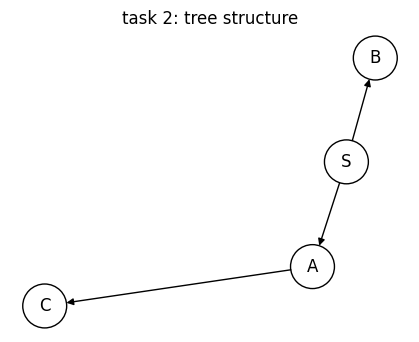

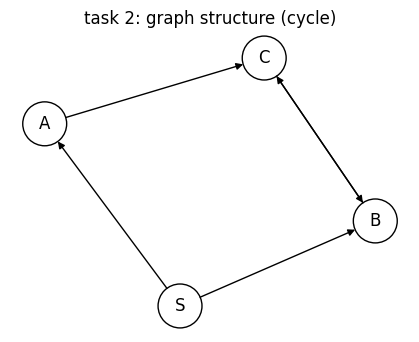


BFS on tree (no visited set)
Step 1: visiting S
Step 2: visiting A
Step 3: visiting B
Step 4: visiting C
goal found

BFS on graph (no visited set)
Step 1: visiting S
Step 2: visiting A
Step 3: visiting B
Step 4: visiting C
goal found

BFS on graph (with visited set)
Step 1: visiting S
Step 2: visiting A
Step 3: visiting B
Step 4: visiting C
goal found


In [36]:
import networkx as nx
import matplotlib.pyplot as plt

tree_adj={
    'S': ['A',B'],
    'A': ['C'],
    'B': [],
    'C': []
}
graph_adj = {
    'S': ['A','B'],
    'A': ['C'],
    'B': ['C'], 
    'C': ['B']  
}

def visualize_task2(adj_dict, title):
    G = nx.DiGraph()
    for node, neighbors in adj_dict.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
    plt.figure(figsize=(4,3))
    nx.draw(G, with_labels=True, node_color='none', edgecolors='black', node_size=1000)
    plt.title(title)
    plt.show()

def run_bfs(adj, use_visited, title):
    print(f"\n{title}")
    queue = ['S']
    visited = set()
    steps = 0
    
    while queue and steps < 10: 
        state = queue.pop(0)
        steps += 1
        print(f"Step {steps}: visiting {state}")

        if state == 'C':
            print("goal found")
            return

        if not use_visited or state not in visited:
            if use_visited: visited.add(state)
            queue.extend(adj.get(state, []))
            
    if steps >= 10: print("result: infinite loop detected")

visualize_task2(tree_adj, "task 2: tree structure")
visualize_task2(graph_adj, "task 2: graph structure (cycle)")

run_bfs(tree_adj, use_visited=False, title="BFS on tree (no visited set)")

run_bfs(graph_adj, use_visited=False, title="BFS on graph (no visited set)")

run_bfs(graph_adj, use_visited=True, title="BFS on graph (with visited set)")

In [21]:
# Task 3

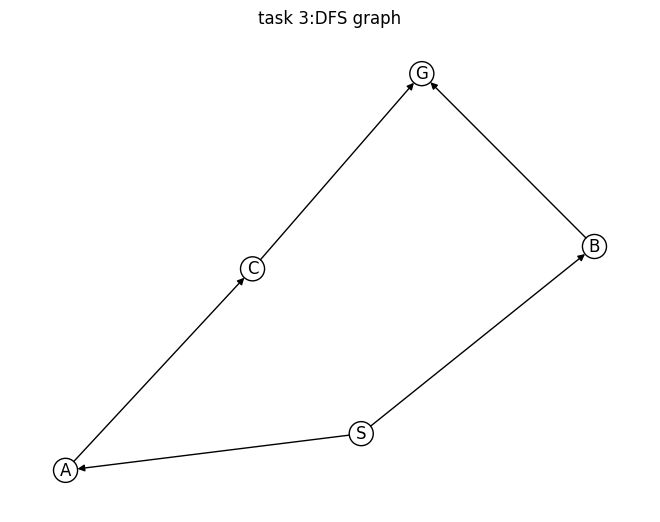

expansion order: ['S', 'B', 'G']
final Path: S,B,G


In [40]:
import networkx as nx
import matplotlib.pyplot as plt
graph = {
    'S': [('A',1),('B',1)],
    'A': [('C',1)],
    'B': [('G', 1)],
    'C': [('G', 1)],
    'G': []
}

initial_state = 'S'
goal_state = 'G'


def get_successors(state):
    return graph.get(state, [])


def visualize():
    G = nx.DiGraph()

    for node in graph:
        for neighbor, cost in graph[node]:
            G.add_edge(node, neighbor)

    nx.draw(G, with_labels=True, node_color='none', edgecolors='black')
    plt.title("task 3:DFS graph")
    plt.show()



def dfs():
    stack = [(initial_state, [initial_state])]  
    visited = set()
    expansion_order = []

    while stack:
        state, path = stack.pop() 

        if state not in visited:
            visited.add(state)
            expansion_order.append(state)

            if state == goal_state:
                return path, expansion_order

            for neighbor, cost in get_successors(state):
                if neighbor not in visited:
                    stack.append((neighbor, path +[neighbor]))

    return None, expansion_order



if __name__ == "__main__":
    visualize()

    path, expansion = dfs()

    print("expansion order:", expansion)
    print("final Path:", ",".join(path))


In [41]:
# Task 4

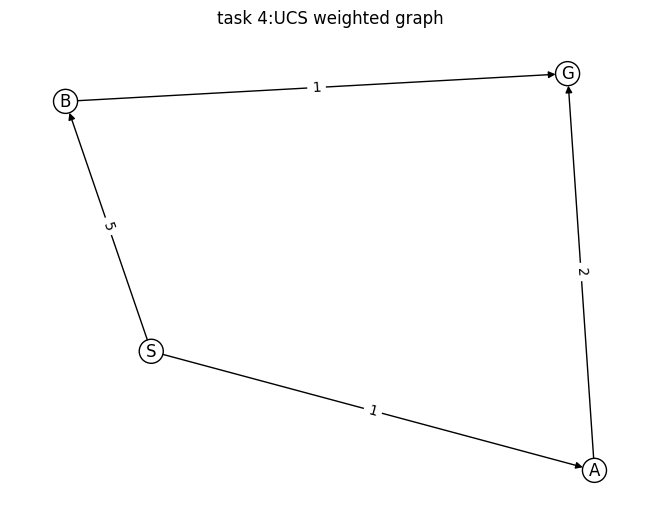

optimal path: S,A,G
total path cost: 3


In [43]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'S': [('A',1),('B',5)],
    'A': [('G',2)],
    'B': [('G',1)],
    'G': []
}

initial_state = 'S'
goal_state = 'G'


def get_successors(state):
    return graph.get(state, [])

def visualize():
    G = nx.DiGraph()

    for node in graph:
        for neighbor, cost in graph[node]:
            G.add_edge(node, neighbor, weight=cost)

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='none', edgecolors='black')

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("task 4:UCS weighted graph")
    plt.show()



def ucs():
    frontier = [(0, initial_state, [initial_state])]
    visited = set()

    while frontier:
        cost, state, path = heapq.heappop(frontier) 

        if state == goal_state:
            return path, cost

        if state not in visited:
            visited.add(state)

            for neighbor, step_cost in get_successors(state):
                if neighbor not in visited:
                    new_cost = cost + step_cost
                    heapq.heappush(frontier, (new_cost, neighbor, path + [neighbor]))

    return None, 0

if __name__ == "__main__":
    visualize()

    path, total_cost = ucs()

    print("optimal path:", ",".join(path))
    print("total path cost:", total_cost)
